# Temperature Calibration for Selected LLMs

## Introduction

In the context of this work (building a system to generate second-level xAI explanations), LLMs are the core component. While they are powerful tools for data analysis, they are also prone to "hallucinations". A key parameter they use is **temperature**, which controls the trade-off between deterministic precision and probabilistic creativity.

In this notebook, we run a mini-experiment to test three different temperature values across the three selected LLMs (Qwen, Pixtral, Idefics) on a subset of the main dataset. The selected values are 0.01, 0.2, and 0.4. All values are kept low because the task requires precision, but the goal is to determine how low the temperature should be to achieve the best performance. To evaluate their behaviour, we use an LLM-as-a-judge approach, where Gemma acts as the evaluator.

In [1]:
# INSTALL DEPENDENCIES
!pip install -q -U "transformers>=4.57.0" google-genai bitsandbytes accelerate qwen-vl-utils==0.0.14 "pillow<12.0" requests tqdm seaborn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 117.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 764.2/764.2 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 93.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 51.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 114.0 MB/s eta 0:00:0000:0

## Section 1: Subset Selection from the Main Dataset

To ensure the robustness of the experiment across the overall project scope, we manually selected 10 representative cases from the initial case base. The selection was designed to cover a diverse range of configurations, allowing us to evaluate the behaviour of the LLMs under varied conditions and ensuring that the conclusions drawn from the experiment are not biased toward a specific type of explanation or model.

Here is a breakdown of the selected cases:

| Library | Scope  | ID     | Dataset                         | Graph Type | AI Model        | Explainer   |
|--------|--------|--------|---------------------------------|------------|-----------------|-------------|
| SHAP   | Local  | 000042 | Diabetes Prediction             | Force      | Ridge           | Linear      |
| SHAP   | Local  | 000121 | Breast Cancer Classification    | Waterfall  | DecisionTree    | Tree        |
| SHAP   | Cohort | 000630 | Fire Prediction                 | Decision   | SVR             | Permutation |
| SHAP   | Global | 000279 | MPG Prediction                  | Heatmap    | MLP             | Kernel      |
| SHAP   | Global | 000356 | Wine Classification             | Beeswarm   | Logistic        | Linear      |
| SHAP   | Global | 000068 | Diabetes Prediction             | Scatter    | SVR             | Kernel      |
| LIME   | Local  | 000975 | Breast Cancer Classification    | Bar        | KerasDNN        | LIME        |
| LIME   | Local  | 001074 | Fire Prediction                 | Dashboard  | Torch           | LIME        |
| ALE    | Global | 001204 | MPG Prediction                  | 1D         | Gradient        | ALE         |
| ALE    | Global | 001250 | Wine Classification             | 2D         | RandomForest    | ALE         |

In [2]:
import pandas as pd

# Load main database
full_df = pd.read_csv('/kaggle/input/datasets/cameronsanchez/temperature-experiment-files/data/raw/xai_case_base.csv', dtype={'id': str})

# IDs selected
subset_ids = [
    '000042', '000121', '000630', '000279', '000356', 
    '000068', '000975', '001074', '001204', '001250'
]

# Create subset
subset_df = full_df[full_df['id'].isin(subset_ids)].copy()

## Section 2: Generation of Outputs Across Temperatures and Models

Once the subset has been obtained, we iterate over the selected temperature values (0.01, 0.2, and 0.4) for each of the three LLMs:
* **Qwen-3-VL-8B**
* **Pixtral-12B**
* **Idefics3-8B**

For every combination of model and temperature, an output is generated for each of the 10 selected cases. This results in a complete set of responses covering all configurations, which are then stored in a CSV file for further analysis and evaluation.

In [3]:
# LOGIN FOR FASTER DOWNLOADS FROM HUGGING FACE

from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

try:
    # Retrieve the token from Kaggle Secrets
    hf_token = UserSecretsClient().get_secret("API_KEY_HUGGING_FACE")
    
    # Authenticate the session
    login(hf_token)
    print("Successfully logged in to Hugging Face! High-speed downloads enabled.")
except Exception as e:
    print(f"Failed to log in. Please check your Kaggle Secrets. Error: {e}")

Successfully logged in to Hugging Face! High-speed downloads enabled.


In [4]:
import os
import sys
import pandas as pd
from tqdm.notebook import tqdm
import logging

logging.disable(logging.CRITICAL) # To not show logs in output

# Add the project path into the system path for imports
PROJECT_PATH = "/kaggle/input/datasets/cameronsanchez/temperature-experiment-files"
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

from src.llms.orchestrator import VisionLLMManager
from src.prompts.prompt_builder import PromptManager

# Experiment Parameters
TEST_TEMPERATURES = [0.01, 0.2, 0.4]
RAW_DATA_PATH = "/kaggle/input/datasets/cameronsanchez/temperature-experiment-files/data/raw"

# Initialize Managers
prompt_manager = PromptManager(version="default")
llm_manager = VisionLLMManager()
available_models = llm_manager.get_available_models()

# List to hold all 90 generations in memory
experiment_results = []

# Nested Generation Loop
for model_name in available_models:
    
    print(f"\n[{model_name}] Loading into VRAM...")
    
    try:
        llm_manager.load_model(model_name)
    except Exception as e:
        print(f"Failed to load {model_name}: {e}.")
        sys.exit(1)

    total_iterations = len(TEST_TEMPERATURES) * len(subset_df)
    
    with tqdm(total=total_iterations, desc=f"Evaluating {model_name}") as pbar:

        # Iterate through the 3 temperature values
        for temp in TEST_TEMPERATURES:
            
            # Iterate through the 10 extracted cases
            for index, case in subset_df.iterrows():
                
                # Force string format with leading zeros
                case_id = str(case['id']).zfill(6)
                
                # Resolve the full path to the image
                image_path = os.path.join(RAW_DATA_PATH, case['img_path'])
                
                # Build the specific prompt for this graph
                prompt = prompt_manager.build(case_data=case.to_dict())
                
                # Generate the insight
                result = llm_manager.generate_with_specific_model(
                    model_name=model_name,
                    image_path=image_path,
                    prompt=prompt,
                    case_id=case_id,
                    temperature=temp
                )

                # STRICT FAIL LOGIC:
                if result.get('error'):
                    print(f"\n[FATAL ERROR] Generation failed for case {case_id} with {model_name} at temp {temp}.")
                    print(f"Error details: {result['error']}")
                    llm_manager.unload_model(model_name)
                    raise RuntimeError("Halting execution to guarantee data integrity.")
                
                # Store the result
                experiment_results.append({
                    'case_id': case_id,
                    'model': model_name,
                    'temperature': temp,
                    'generated_insight': result.get('insight', ''),
                    'generation_error': result.get('error', '')
                })
                
                pbar.update(1) # Update progress bar
                
    print(f"[{model_name}] Unloading from VRAM...")
    llm_manager.unload_model(model_name)

# Convert results to a DataFrame
results_df = pd.DataFrame(experiment_results)

# Save the results into a csv file
output_csv_path = "temperature_experiment_outputs.csv"
results_df.to_csv(output_csv_path, index=False)

print("\n--- Generation Complete ---")


[Qwen-3-VL-8B] Loading into VRAM...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/951 [00:00<?, ?B/s]

Evaluating Idefics3-8B:   0%|          | 0/30 [00:00<?, ?it/s]

[Idefics3-8B] Unloading from VRAM...

--- Generation Complete ---


> ⚠️ **Note:** Sections 3 and 4 are executed in a local environment due to Kaggle GPU quota limitations.

## Section 3: Evaluation via LLM-as-a-Judge

After generating an output for every combination of temperature and model across all selected cases, the next step is to evaluate their behaviour. To do this, we adopt the LLM-as-a-judge approach, which has been shown to produce reliable results in recent research.

In this experiment, we use **Gemma 4 31B (Google)**, an open-source multimodal LLM. This model supports both text and image inputs and is particularly strong in reasoning, coding, and document understanding tasks. It features a large context window (up to 256K tokens), multilingual capabilities, and configurable reasoning modes, making it well-suited for evaluating complex outputs that require both visual and contextual understanding.

To access the model, we use the Google AI Studio API. While OpenRouter was initially considered due to its free access to the model, its rate limits proved restrictive for this experiment. In contrast, Google AI Studio provides more suitable usage limits (e.g., higher requests per minute and daily quotas), enabling a smoother and more scalable evaluation process.

The evaluation process is based on a structured prompt that includes the metadata of the analysed graph, the corresponding image, the generated explanation to be evaluated, and clear instructions defining the role, task, and expected output format. The judge model is configured with a temperature of 0.0 to ensure deterministic and consistent evaluations.

More specifically, the prompt assigns the model the role of a Senior xAI Audit Engineer and asks it to assess the factuality of the generated explanation against the ground truth (image and metadata). It performs checks for unsupported claims (features not present in the graph), contradictions between the explanation and the visual evidence, and formatting issues. The model is required to return a structured JSON output containing a reasoning trace, a categorical evaluation label, and numerical scores for instruction following and factuality. Additionally, the prompt explicitly requests chain-of-thought reasoning, as including intermediate reasoning steps has been shown to significantly improve the performance and reliability of LLM-based evaluators, particularly in technical tasks such as the analysis of data visualizations.

In [ ]:
import json
import re
import os
import time
import pandas as pd
from PIL import Image
from tqdm import tqdm
from dotenv import load_dotenv
from google import genai
from google.genai import types

# API SETUP

load_dotenv()
GEMINI_API_KEY = os.getenv("API_KEY_GEMINI")

if not GEMINI_API_KEY:
    raise ValueError("API_KEY_GEMINI not found in .env file.")

# Initialize the new Client
client = genai.Client(api_key=GEMINI_API_KEY)

# Define the model (AI Studio)
MODEL_NAME = "gemma-4-31b-it"


# LOCAL PATHS & DATA LOADING

PROJECT_ROOT = ".." 
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "xai_rag_cbr", "data", "raw")
BASE_CASE_CSV = os.path.join(RAW_DATA_PATH, "xai_case_base.csv")

INPUT_RESULTS_CSV = "temperature_experiment_outputs.csv"
OUTPUT_FILE = "temperature_experiment_evaluation.csv"
PARTIAL_FILE = "partial_temperature_experiment_evaluation.csv"

# Recreate subset_df locally
full_df = pd.read_csv(BASE_CASE_CSV, dtype={'id': str})
subset_ids = ['000042', '000121', '000630', '000279', '000356', '000068', '000975', '001074', '001204', '001250']
subset_df = full_df[full_df['id'].isin(subset_ids)].copy()

# Load results from the outputs CSV
results_df = pd.read_csv(INPUT_RESULTS_CSV, dtype={'case_id': str})
results_df['generated_insight'] = results_df['generated_insight'].fillna("No insight generated.")


# JUDGE FUNCTION

def get_judge_evaluation(generated_insight, ground_truth_row, image_path):
    
    # Load the image in full quality
    img = Image.open(image_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Escape curly braces for f-string safety
    safe_insight = str(generated_insight).replace('{', '{{').replace('}', '}}')
    
    prompt_text = f"""
    # ROLE
    You are a Senior xAI Audit Engineer. Evaluate the FACTUALITY of the generated explanation against the attached GROUND TRUTH IMAGE and METADATA.

    # GROUND TRUTH METADATA
    * **Domain:** {ground_truth_row['domain']}
    * **AI Task:** {ground_truth_row['ai_task']}
    * **Problem Type:** {ground_truth_row['ai_problem_type']}
    * **Input Data Format:** {ground_truth_row['input_format']}
    * **Target Analyzed:** {ground_truth_row['class']} (Specific class, local value, or NA)
    * **AI Model:** {ground_truth_row['ai_model']}
    * **xAI Library:** {ground_truth_row['library']}
    * **Explainer Used:** {ground_truth_row['explainer']}
    * **Graph Type:** {ground_truth_row['xai_graph_type']}
    * **Scope:** {ground_truth_row['scope']}
    * **Portability:** {ground_truth_row['portability']}
    * **Concurrency:** {ground_truth_row['concurrency']}
    * **Features Displayed:** {ground_truth_row['attributes']}

    # GENERATED INSIGHT TO EVALUATE
    "{safe_insight}"

    # TASK
    1. Read and analyse the attached image carefully. 
    2. Check if the insight mentions features NOT in the 'Features Displayed' list (Unsupported Claim).
    3. Check if the direction/magnitude of impact contradicts visual evidence (Contradiction).
    4. Check if it followed single-paragraph formatting (Formatting Error).

    # OUTPUT FORMAT
    You must respond ONLY with a valid JSON object matching this schema:
    {{
      "chain_of_thought_reasoning": "Step-by-step analysis comparing the insight to the visual evidence and metadata ground truth...",
      "response_state": "Perfect" | "Formatting Only" | "Unsupported Claim" | "Contradiction",
      "instruction_following_score": 1-5,
      "factuality_score": 1-5
    }}
    """

    # Call the API client with the Types configuration for JSON
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=[prompt_text, img],
        config=types.GenerateContentConfig(
            temperature=0.0,
            response_mime_type="application/json"
        )
    )
    
    content = response.text

    # Robust Regex fallback to extract JSON safely
    json_match = re.search(r'(\{.*\})', content, re.DOTALL)
    if json_match:
        return json.loads(json_match.group(1))
    else:
        raise ValueError(f"Judge output did not contain valid JSON. Raw output: {content}")


# EVALUATION LOOP

evaluation_data = []
done_set = set()

if os.path.exists(PARTIAL_FILE):
    try:
        # Attempt to read the partial file
        completed_df = pd.read_csv(PARTIAL_FILE, dtype={'case_id': str})
        if not completed_df.empty:
            print(f"Resuming from partial progress ({len(completed_df)} cases found).")
            evaluation_data = completed_df.to_dict('records')
            done_set = set(zip(
                completed_df['case_id'].astype(str).str.zfill(6), 
                completed_df['model'], 
                completed_df['temperature']
            )) 
    except (pd.errors.EmptyDataError, pd.errors.ParserError):
        print("Partial file is corrupted or empty. Starting from scratch.")
        os.remove(PARTIAL_FILE)
else:
    print("No partial progress found. Starting fresh evaluation.")

print(f"Starting evaluation. (Found {len(done_set)} cases already completed)")

retry_delay = 10

for index, row in tqdm(results_df.iterrows(), total=len(results_df), desc="Judging Inferences"):

    case_id = str(row['case_id']).zfill(6)
    model, temp = row['model'], row['temperature']
    
    if (case_id, model, temp) in done_set:
        continue
    
    ground_truth_row = subset_df[subset_df['id'] == case_id].iloc[0]
    image_path = os.path.join(RAW_DATA_PATH, ground_truth_row['img_path'])
    
    max_retries, success = 5, False

    for attempt in range(max_retries):
        try:
            judge_output = get_judge_evaluation(row['generated_insight'], ground_truth_row, image_path)
            evaluation_data.append({
                'case_id': case_id, 'model': model, 'temperature': temp,
                'chain_of_thought_reasoning': judge_output.get('chain_of_thought_reasoning', 'Missing'),
                'response_state': judge_output.get('response_state', 'Parse Error'),
                'instruction_following_score': judge_output.get('instruction_following_score', 0),
                'factuality_score': judge_output.get('factuality_score', 0)
            })
            retry_delay = 10
            success = True
            break

        except Exception as e:
            error_str = str(e).lower()
            if "429" in error_str or "quota" in error_str or "exhausted" in error_str:
                print(f"Rate limit hit. Retrying in {retry_delay}s... (Attempt {attempt+1})")
                time.sleep(retry_delay)
                retry_delay *= 2
            else: 
                pd.DataFrame(evaluation_data).to_csv(PARTIAL_FILE, index=False)
                raise e

    if not success:
        pd.DataFrame(evaluation_data).to_csv(PARTIAL_FILE, index=False)
        raise RuntimeError(f"Failed on case {case_id}")
    
    pd.DataFrame(evaluation_data).to_csv(PARTIAL_FILE, index=False)
    
    time.sleep(5.0) # Cooldown margin to pace the 15 RPM limit (60s / 15 = 4s)


# FINAL EXPORT

eval_results_df = pd.DataFrame(evaluation_data)
eval_results_df.to_csv(OUTPUT_FILE, index=False)
# Clean up partial file once done
if os.path.exists(PARTIAL_FILE):
    os.remove(PARTIAL_FILE)

print("\n--- Evaluation Complete ---")

Resuming from partial progress (37 cases found).
Starting evaluation. (Found 37 cases already completed)


Judging Inferences: 100%|██████████| 90/90 [45:51<00:00, 30.57s/it]


--- Evaluation Complete ---


## Section 4: Results and Comparative Analysis

In this section, we analyse the results obtained from the evaluation process and compare the performance of the different model–temperature configurations. The goal is to identify patterns in terms of factuality, error types, and consistency across cases. To achieve this, we use a set of complementary visualisations that provide both quantitative and qualitative insights into model behaviour. These charts allow us to determine which configurations offer the most reliable and accurate outputs for the task.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load final local evaluation data
eval_results_df = pd.read_csv("temperature_experiment_evaluation.csv")

# Visual style for the plots
sns.set_theme(style="whitegrid")
palette = {
    "Perfect": "#2ecc71", 
    "Formatting Only": "#3498db", 
    "Unsupported Claim": "#f39c12", 
    "Contradiction": "#e74c3c", 
    "API Error": "#95a5a6"
}

### 4.1: Average Factuality (Heatmap)

The heatmap provides a broad view of model performance. Higher scores (closer to 5.0) indicate the optimal configuration, where a model effectively balances accurate technical interpretation without introducing unnecessary noise.

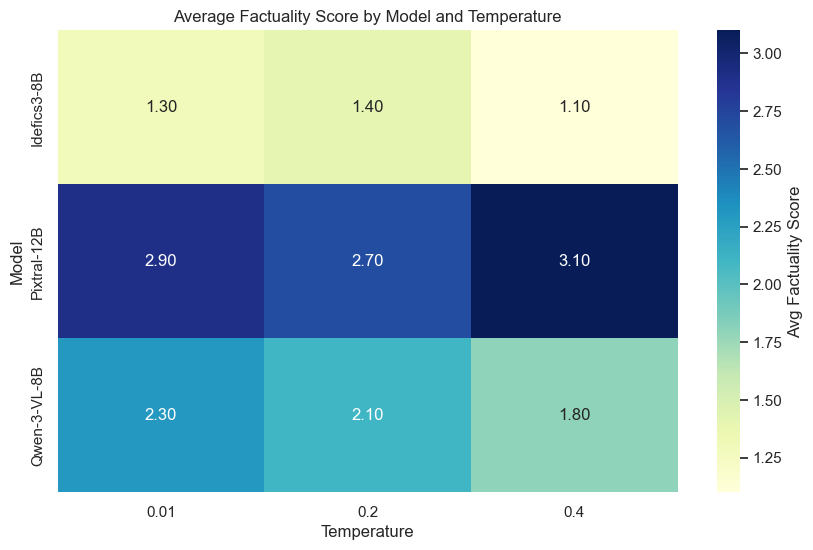

In [5]:
# First we calculate mean factuality_score per model and temperature
heatmap_data = eval_results_df.pivot_table(
    index='model', 
    columns='temperature', 
    values='factuality_score', 
    aggfunc='mean'
)

# Finally we plot the obtained results
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Avg Factuality Score'})
plt.title("Average Factuality Score by Model and Temperature")
plt.xlabel("Temperature")
plt.ylabel("Model")
plt.show()

The heatmap reveals a clear performance hierarchy across the three models, mostly
independent of temperature. **Pixtral-12B** consistently achieves the highest factuality
scores across all temperature settings (ranging from 2.70 to 3.10), establishing itself
as the most factually reliable model in this experiment. **Qwen-3-VL-8B** occupies a
middle ground (1.80–2.30), while **Idefics3-8B** scores the lowest across the board
(1.10–1.40), suggesting it struggles to produce factually grounded explanations
regardless of the temperature used.

Regarding the effect of temperature, no universal trend is observed. For **Pixtral-12B**,
factuality peaks at the highest temperature tested (3.10 at T=0.4), which is
counterintuitive and may suggest that some degree of generation diversity benefits its
outputs in this task. In contrast, **Qwen-3-VL-8B** shows a monotonically decreasing
trend as temperature increases (2.30 → 2.10 → 1.80), indicating that lower temperatures
favour factual accuracy for this model. **Idefics3-8B** shows no meaningful sensitivity to
temperature changes.

It is also worth noting that even the best-performing configuration (**Pixtral-12B** at
T=0.4, score 3.10) sits at roughly 62% of the maximum possible score of 5.0, indicating
that factuality remains a general challenge across all tested configurations.

### 4.2: Error Typology (Stacked Bar Chart)

While average scores show overall quality, they do not capture the nature of failures. This chart classifies each response into a specific category. In the context of xAI, Contradictions are critical failures, whereas Formatting Errors are minor issues that can be fixed with better prompting.

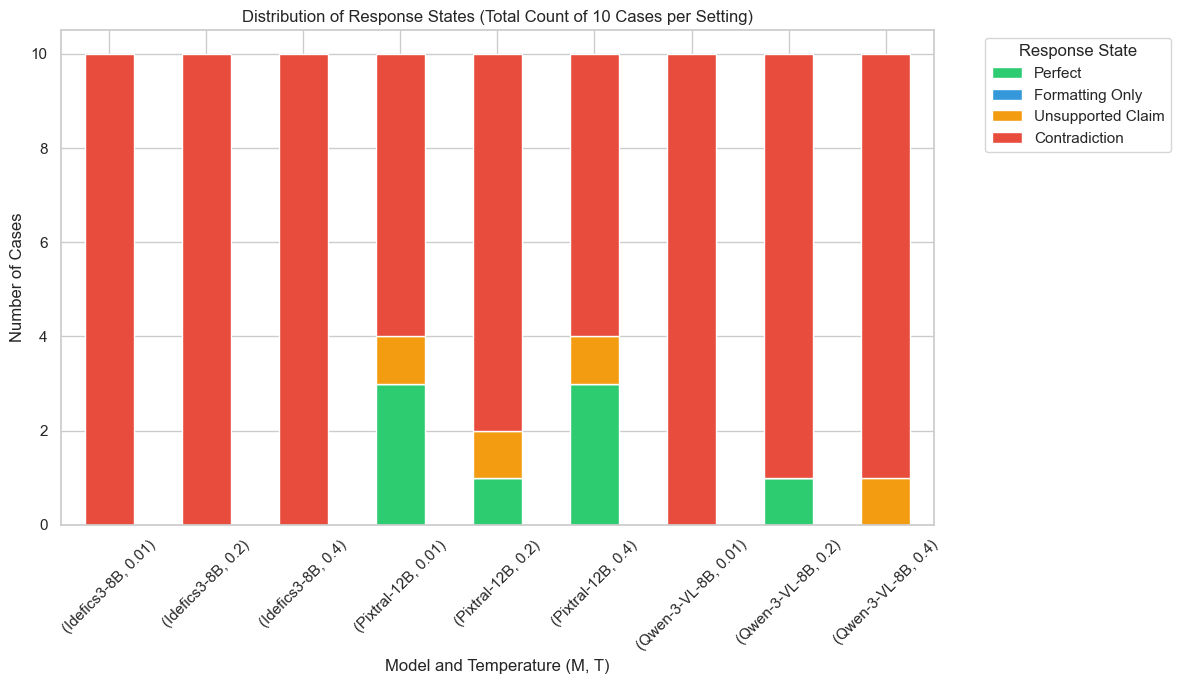

In [6]:
# First we group by model/temp and count the occurrences of each response_state
order = ["Perfect", "Formatting Only", "Unsupported Claim", "Contradiction"]
pivot_df = eval_results_df.groupby(['model', 'temperature', 'response_state']).size().unstack(fill_value=0)

# Then we ensure all categories are present for consistent plotting
for col in order:
    if col not in pivot_df.columns:
        pivot_df[col] = 0
pivot_df = pivot_df[order]

# Finally we plot the obtained results
pivot_df.plot(kind='bar', stacked=True, color=[palette[c] for c in order], figsize=(12, 7))
plt.title("Distribution of Response States (Total Count of 10 Cases per Setting)")
plt.xlabel("Model and Temperature (M, T)")
plt.ylabel("Number of Cases")
plt.legend(title="Response State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The stacked bar chart exposes a critical finding: **"Contradiction" is the dominant failure mode across basically all model-temperature combinations**. This highlights that interpreting these specific xAI graphs and generating accurate explanations is a highly complex task for these vision-language models, as already identified in section 4.1. The core of the problem is that outputs actively conflict with the information present in the xAI graph and metadata. 

**Idefics3-8B** shows the most severe behaviour: every single response across all three temperatures is classified as a "Contradiction" (10/10 in all settings). This makes it the weakest performer by a considerable margin, showing no meaningful variation across temperatures.

**Pixtral-12B** is the only model that produces a meaningful number of "Perfect" responses, reaching 3 out of 10 at both T=0.01 and T=0.4. It also registers isolated "Unsupported Claim" cases (1 at T=0.2 and T=0.4), which, while not ideal, represent a less critical failure than outright contradiction. Still, "Contradictions" remain the majority even for this model (6–9 out of 10 depending on the temperature).

**Qwen-3-VL-8B** produces only 1 "Perfect" response (at T=0.2) and 1 "Unsupported Claim" (at T=0.4), with "Contradictions" dominating across all settings. This is consistent with its mid-range factuality scores seen in the heatmap.

Notably, the **"Formatting Only"** category is entirely absent across all configurations, but this does not mean all models respected the output format. Rather, it reflects the classification logic: when a response both violates formatting and contains a contradiction or an unsupported claim, the more severe content-related label is assigned. Revising the csv file, we can observe that **Qwen-3-VL-8B and Pixtral-12B consistently respected the output format**, while **Idefics3-8B did present formatting failures** that did not surface as a standalone category because they always co-occurred with more critical content errors.

Overall, this chart reinforces that the bottleneck in this experiment is semantic faithfulness to the graph and metadata (ground truth), not minor or recoverable issues.

### 4.3: Model Stability and Variance (Box Plot)

A high average score is only meaningful if the model is consistent. The box plot illustrates the distribution of factuality scores. A narrow box indicates stable and predictable behaviour, while a wider spread reflects higher variance, where the model may perform very well on some cases but fail on others.

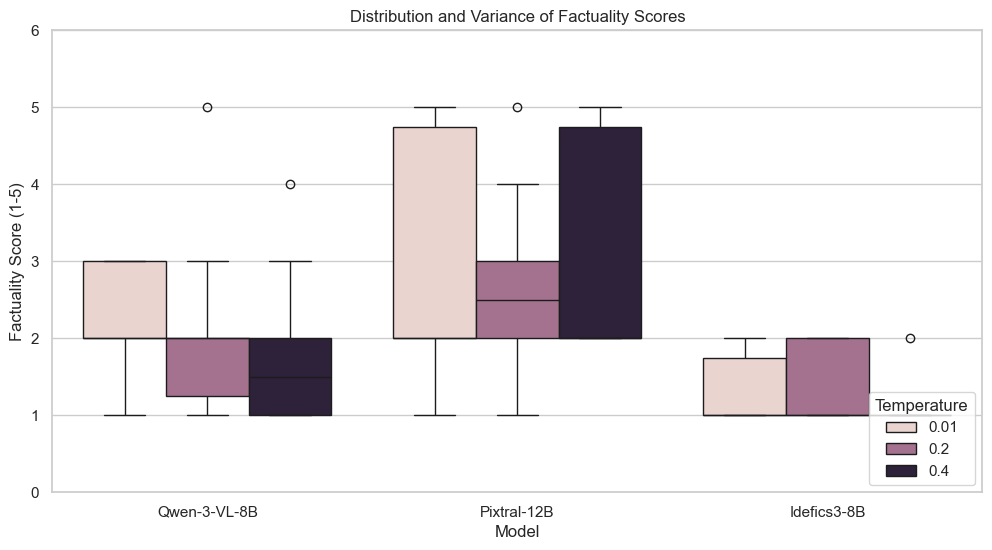

In [7]:
# We plot the obtained results
plt.figure(figsize=(12, 6))
sns.boxplot(data=eval_results_df, x='model', y='factuality_score', hue='temperature')
plt.title("Distribution and Variance of Factuality Scores")
plt.xlabel("Model")
plt.ylabel("Factuality Score (1-5)")
plt.legend(title="Temperature", loc='lower right')
plt.ylim(0, 6)
plt.show()

The box plot adds a meaningul insight to the conclusions obtained from the previous graphs: **high average performance and high variance can  coincide**, and this is key when selecting the optimal configuration for the system.

**Pixtral-12B** confirms its position as the top-performing model but reveals a significant stability concern: the high averages mask extreme volatility. At T=0.01, it exhibits the widest interquartile range of all configurations, spanning roughly from 1 to 4.75, meaning its outputs are highly unpredictable (capable of almost perfect responses but equally capable of close to failure within the same setting). At T=0.4, the median rises noticeably (close to 4.75) and the distribution shifts upward, suggesting that higher temperature not only increases the average score (as seen in 4.1) but also provides a more consistently high-quality output for this model. T=0.2 appears as the least stable setting for Pixtral-12B, with a compressed IQR but an outlier reaching 5, suggesting occasional strong outputs among bad performance.

**Qwen-3-VL-8B** shows moderate and relatively consistent variance across temperatures, with a slight upward shift at T=0.01 compared to T=0.2 and T=0.4. Notably, isolated high-scoring outliers appear at T=0.01 (reaching 5) and T=0.2 (reaching 4), indicating the model can occasionally produce good explanations but cannot sustain that quality reliably.

**Idefics3-8B** is the most stable model, but for the wrong reason. Its boxes are narrow and clustered near the bottom of the scale across all temperatures, with only a single outlier at 2 for T=0.4. This low variance reflects consistent underperformance rather than reliability, positioning it as the least suitable of the three models for this task in its current configuration.

Overall, the box plot suggests that **Pixtral-12B at T=0.4 offers the best combination of high median score and relatively concentrated distribution**, making it the most promising configuration identified so far, though the remaining variance still indicates room for improvement.

## Section 5: Validation of the LLM-as-a-Judge

To ensure the reliability of the evaluation framework, we introduce a validation step based on a Human-in-the-Loop (HITL) approach. While LLM-as-a-judge methods provide scalable and consistent evaluations, they are still susceptible to errors such as hallucinations or incorrect reasoning. Therefore, we manually inspect a representative subset of the evaluated cases to verify the correctness of the judge’s outputs. Concretely, a random sample of 6 cases per model (18 in total, corresponding to 20% of the dataset) is selected. For each case, we review the original graph (ground truth), the generated explanation, and the evaluation produced by the judge model. This process allows us to assess whether the judge correctly identifies contradictions, unsupported claims, and formatting issues, as well as whether its scoring is aligned with human expert judgment. This validation step acts as a safeguard, ensuring that the evaluation itself is trustworthy and reducing the risk of propagating errors from the judge model into the final conclusions of the experiment.


## CASE 1: ID `001074`
**Generator Model:** `Idefics3-8B` | **Temperature:** `0.4`


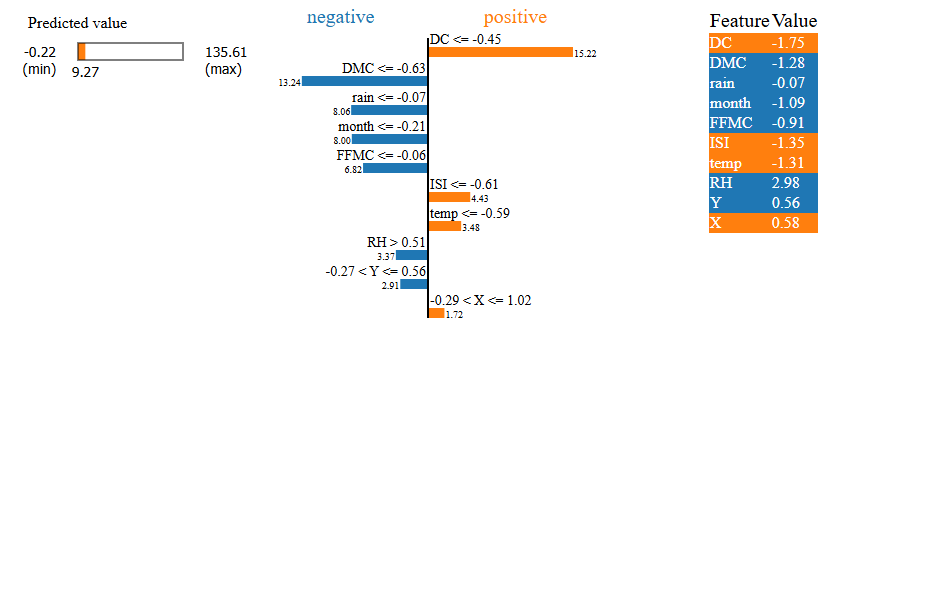


### Generated Insight
> * The graph is a dashboard displaying the importance of various features in predicting the burned area of forest fires. The features are X, Y, month, day, FFMC, DMC, DC, ISI, temp, RH, wind, and rain. The y-axis represents the feature values, with negative values indicating a negative effect on the prediction and positive values indicating a positive effect. The x-axis represents the feature names. The graph shows that FFMC has the highest positive effect on the prediction, followed by DC, ISI, and temp. On the other hand, Y, month, and RH have the most negative effects on the prediction. The magnitude of their importance varies, with FFMC being the most influential feature, followed by DC and ISI.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Feature Verification**: The insight lists features (X, Y, month, day, FFMC, DMC, DC, ISI, temp, RH, wind, rain) which match the 'Features Displayed' metadata. No unsupported claims regarding feature names.
2. **Axis Analysis**: The insight states the y-axis represents feature values and the x-axis represents feature names. Looking at the image, the y-axis lists the feature names/conditions, and the x-axis represents the magnitude of the effect (positive/negative). This is a contradiction.
3. **Direction/Magnitude Analysis**: 
    - The insight claims 'FFMC has the highest positive effect'. In the image, FFMC is on the negative side (blue bar, value 6.82). DC actually has the highest positive effect (orange bar, value 15.22). This is a direct contradiction.
    - The insight claims 'Y, month, and RH have the most negative effects'. While they are negative, DMC (13.24), rain (8.06), and month (8.00) have larger negative magnitudes than Y (2.91) and RH (3.37).
    - The insight claims 'FFMC being the most influential feature'. The most influential feature is the one with the largest absolute value, which is DC (15.22), followed by DMC (13.24). FFMC is not the most influential. This is a contradiction.
4. **Formatting**: The insight is provided as a single paragraph, so there is no formatting error.
* **Final State:** `Contradiction`
* **Factuality Score:** `1 / 5`
* **Instruction Score:** `5 / 5`



## CASE 2: ID `000630`
**Generator Model:** `Idefics3-8B` | **Temperature:** `0.2`


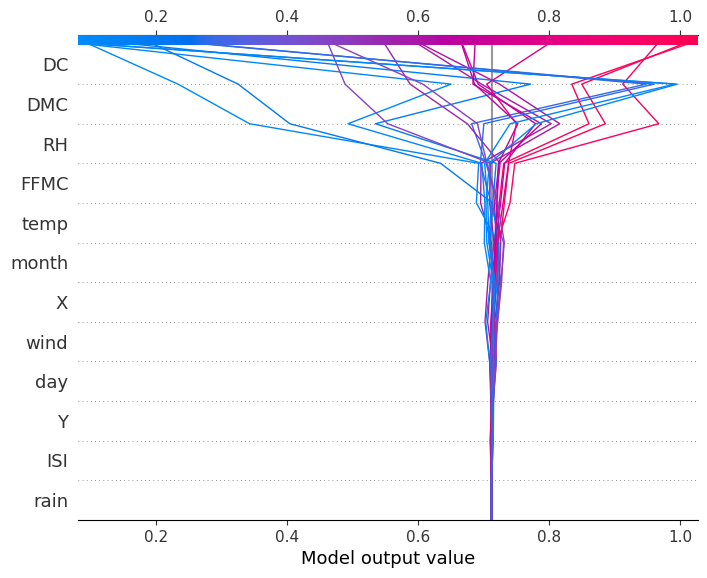


### Generated Insight
> * The visual graph represents the decision-making process of a Support Vector Regression (SVR) model in predicting forest fire burned area. The model's output is shown on the x-axis, ranging from 0 to 1.0. The y-axis represents the features influencing the model's prediction. The features displayed are X, Y, month, day, FFMC (Fuel Moisture Code), DMC (Drought Code), DC (Drought Code), ISI (Initial Spread Index), temp (temperature), RH (Relative Humidity), wind, and rain. The graph uses a decision tree visualization, with each feature represented by a different color line.

The features driving the model's decision are DC (Drought Code), DMC (Drought Code), and RH (Relative Humidity). These features have the most significant impact on the model's prediction. The direction of their impact is negative, meaning that higher values of these features lead to a lower predicted burned area. The magnitude of their importance relative to each other is as follows: DC (Drought Code) has the highest impact, followed by DMC (Drought Code), and then RH (Relative Humidity). The other features, such as X, Y, month, day, FFMC, ISI, temp, wind, and rain, have a lesser impact on the model's prediction.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Analyze Metadata vs. Insight**: The metadata specifies the graph type as 'Decision' (referring to a SHAP Decision Plot) and the model as SVR. The insight correctly identifies the model (SVR) and the features displayed. 
2. **Analyze Visual Evidence (Image)**: 
    - The image is a SHAP Decision Plot. The x-axis is the 'Model output value'. The y-axis lists features. 
    - In a SHAP Decision Plot, each line represents a single data sample, and the color of the line represents the model's output value (blue for low, red for high). 
    - The horizontal movement of a line at a feature's row indicates the contribution (SHAP value) of that feature to the prediction. 
3. **Evaluate Claims**: 
    - **Claim**: 'The graph uses a decision tree visualization'. **Verdict**: Contradiction. This is a SHAP Decision Plot, not a decision tree. 
    - **Claim**: 'each feature represented by a different color line'. **Verdict**: Contradiction. Lines represent samples, and colors represent the output value, not features. 
    - **Claim**: 'The direction of their impact is negative, meaning that higher values of these features lead to a lower predicted burned area'. **Verdict**: Contradiction. In the plot, the red lines (high output) are pushed to the right (positive contribution) and blue lines (low output) are pushed to the left (negative contribution) for DC, DMC, and RH. This indicates a positive relationship between these features' contributions and the final output, not a negative one. 
    - **Claim**: 'DC... highest impact, followed by DMC... then RH'. **Verdict**: Correct. The horizontal spread is greatest for DC, then DMC, then RH. 
4. **Check Formatting**: The insight is written in two paragraphs. The task specifically asked to check for 'single-paragraph formatting'. This is a formatting error. 
5. **Conclusion**: The insight contains multiple factual contradictions regarding the nature of the visualization and the interpretation of the data.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `3 / 5`



## CASE 3: ID `000279`
**Generator Model:** `Idefics3-8B` | **Temperature:** `0.4`


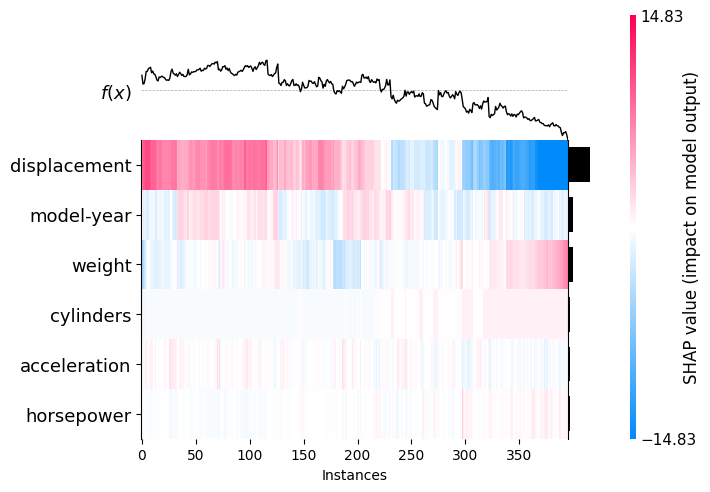


### Generated Insight
> * The SHAP value heatmap reveals the contributions of various features to the model's prediction. The feature "horsepower" has a positive impact on the predicted fuel efficiency, indicating that higher horsepower generally correlates with better MPG. Conversely, "cylinders" negatively affects the prediction, suggesting that more cylinders often lead to lower MPG. The feature "displacement" has a mixed impact, with both positive and negative contributions depending on the specific value. "Weight" also has a mixed effect, with higher weights sometimes leading to better MPG and other times to worse MPG. The "model-year" and "acceleration" features have a less significant impact on the prediction, with "model-year" having a slight positive effect and "acceleration" a slight negative effect.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. Analyze the heatmap structure: The x-axis represents instances, sorted by the model's prediction f(x) (the line at the top), which decreases from left to right. Red indicates a positive SHAP value (increasing the prediction), and blue indicates a negative SHAP value (decreasing the prediction).
2. Evaluate 'displacement': The insight claims a 'mixed impact'. However, the image shows a very clear and strong gradient from red (left/high f(x)) to blue (right/low f(x)), indicating a consistent positive correlation with the prediction. This is a contradiction.
3. Evaluate 'weight': The insight claims a 'mixed effect'. The image shows a clear gradient from blue (left/high f(x)) to red (right/low f(x)), indicating a consistent negative correlation with the prediction. This is a contradiction.
4. Evaluate 'horsepower': The insight claims a 'positive impact'. In the image, the horsepower row is predominantly white/neutral, showing very little impact compared to displacement. This is a contradiction.
5. Evaluate 'cylinders': The insight claims it 'negatively affects the prediction'. The image shows the row is mostly white, with some light red (positive impact) appearing on the right side. This contradicts the claim of a negative effect.
6. Check for unsupported claims: All features mentioned (horsepower, cylinders, displacement, weight, model-year, acceleration) are present in the 'Features Displayed' list.
7. Check formatting: The insight is provided as a single paragraph.
* **Final State:** `Contradiction`
* **Factuality Score:** `1 / 5`
* **Instruction Score:** `5 / 5`



## CASE 4: ID `001074`
**Generator Model:** `Idefics3-8B` | **Temperature:** `0.2`


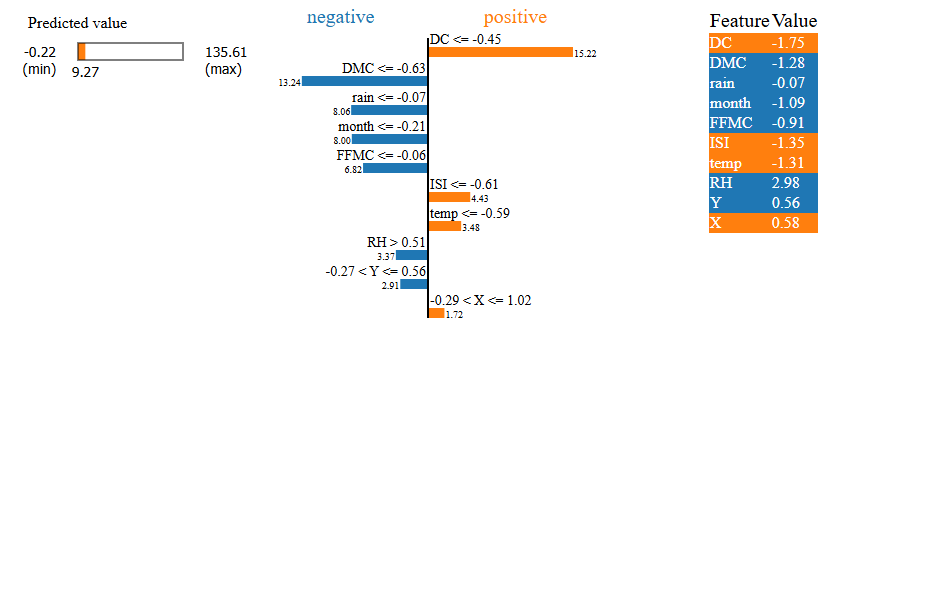


### Generated Insight
> * The graph visualizes the importance of various features in predicting the burned area in forest fires using a TorchRegressor model. The x-axis represents the features, while the y-axis indicates the feature values. The color gradient from blue to orange signifies the positive and negative impact of each feature on the prediction, with blue indicating a negative effect and orange indicating a positive effect. The magnitude of the importance is represented by the size of the bars. The features driving the model's decision are DC, FFMC, ISI, and RH. DC has the highest positive impact, followed by FFMC, ISI, and RH. The feature with the most negative impact is Y.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. Analysis of Axes: The insight states the x-axis represents features and the y-axis represents feature values. In the provided LIME plot, the y-axis lists the features (DC, DMC, etc.) and the x-axis represents the impact/weight of those features on the prediction. This is a factual error.
2. Analysis of Impact Direction: The insight claims DC, FFMC, ISI, and RH have positive impacts. Looking at the image, DC and ISI are orange (positive), but FFMC and RH are blue (negative). This is a contradiction.
3. Analysis of Magnitude: The insight claims DC has the highest positive impact (Correct: 15.22), followed by FFMC, ISI, and RH. This is incorrect as FFMC and RH are negative. The positive sequence is DC > ISI > temp > X.
4. Analysis of Most Negative Impact: The insight claims Y has the most negative impact. Looking at the image, the longest blue bar is DMC (13.24), followed by rain (8.06), month (8.00), and FFMC (6.82). Y has a relatively small negative impact (2.91). This is a contradiction.
5. Feature Check: All mentioned features (DC, FFMC, ISI, RH, Y) are present in the 'Features Displayed' metadata list.
6. Formatting Check: The insight is a single paragraph, so there is no formatting error.
* **Final State:** `Contradiction`
* **Factuality Score:** `1 / 5`
* **Instruction Score:** `5 / 5`



## CASE 5: ID `001204`
**Generator Model:** `Idefics3-8B` | **Temperature:** `0.01`


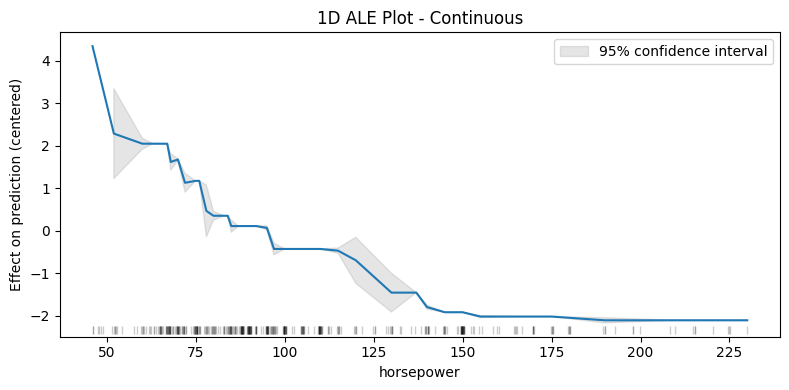


### Generated Insight
> * The attached graph is a 1D plot of the ALE (All-Else Equal) method, which is a model-agnostic technique for explaining the decisions made by a GradientBoostingRegressor. The x-axis represents the horsepower of a vehicle, while the y-axis shows the effect on the predicted fuel efficiency (MPG). The plot is centered at 0, indicating that the baseline MPG is 0. The graph shows that as the horsepower increases, the predicted MPG decreases. This indicates that higher horsepower vehicles tend to have lower fuel efficiency. The effect on MPG is negative, meaning that an increase in horsepower leads to a decrease in MPG. The magnitude of the effect is significant, with a drop in MPG of approximately 2-3 units for every 100 units of horsepower increase.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. Metadata Verification: The insight correctly identifies the plot as a 1D ALE plot, the model as a GradientBoostingRegressor, the feature as horsepower, and the target as fuel efficiency (MPG). 2. Trend Analysis: The insight correctly identifies the inverse relationship (as horsepower increases, MPG decreases). 3. Centering Interpretation: The insight claims 'the baseline MPG is 0' because the plot is centered at 0. This is a conceptual error; in ALE plots, centering at 0 means the effect is relative to the average prediction, not that the actual target value (MPG) is 0. 4. Magnitude Analysis: The insight claims a drop of 'approximately 2-3 units for every 100 units of horsepower increase'. Looking at the graph, at x=50, the effect is ~4.5; at x=150, the effect is ~-2.0. This is a total drop of approximately 6.5 units over 100 units of horsepower. The claimed magnitude (2-3) contradicts the visual evidence (6.5). 5. Formatting: The insight is a single paragraph, so there is no formatting error. 6. Unsupported Claims: No features outside of 'horsepower' were mentioned.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 6: ID `001250`
**Generator Model:** `Idefics3-8B` | **Temperature:** `0.01`


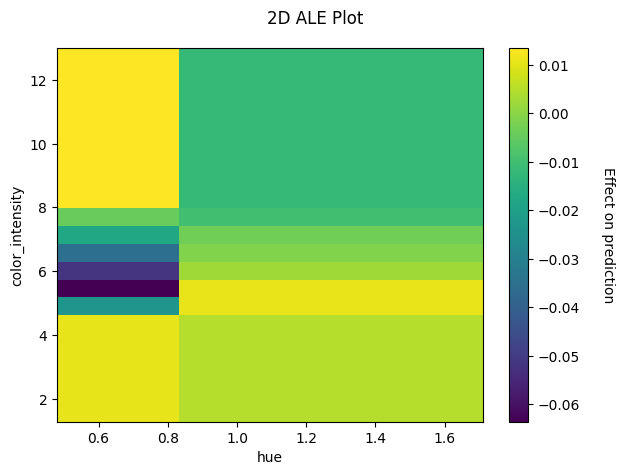


### Generated Insight
> * The 2D ALE plot reveals that the features color_intensity and hue significantly influence the model's decision in the wine cultivar classification task. The color_intensity feature has a positive effect on the prediction, with a value of 0.01, indicating that higher intensity colors are associated with class_1. Conversely, the hue feature has a negative effect, with a value of -0.6, suggesting that certain hues are less likely to be classified as class_1. The magnitude of their importance is evident from the plot, with color_intensity having a more significant impact than hue.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. Feature Verification: The insight mentions 'color_intensity' and 'hue', both of which are listed in the 'Features Displayed' metadata and appear as the axes of the 2D ALE plot. No unsupported features are mentioned.
2. Value Verification (color_intensity): The insight claims a positive effect with a value of 0.01. The color bar in the image shows a maximum value of 0.01 (yellow), which aligns with the visual evidence.
3. Value Verification (hue): The insight claims the hue feature has a negative effect with a value of -0.6. However, the color bar clearly shows the minimum value is -0.06. This is a significant factual contradiction (a decimal place error).
4. Magnitude Analysis: The insight claims color_intensity has a more significant impact than hue. Visually, the variation along the y-axis (color_intensity) spans the full range of the color bar (from 0.01 to -0.06), whereas the variation along the x-axis (hue) is less pronounced for most slices, though it does vary. While this part is arguably correct, the specific value provided for hue is wrong.
5. Formatting: The insight is presented as a single paragraph, adhering to formatting requirements.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 7: ID `000042`
**Generator Model:** `Pixtral-12B` | **Temperature:** `0.01`


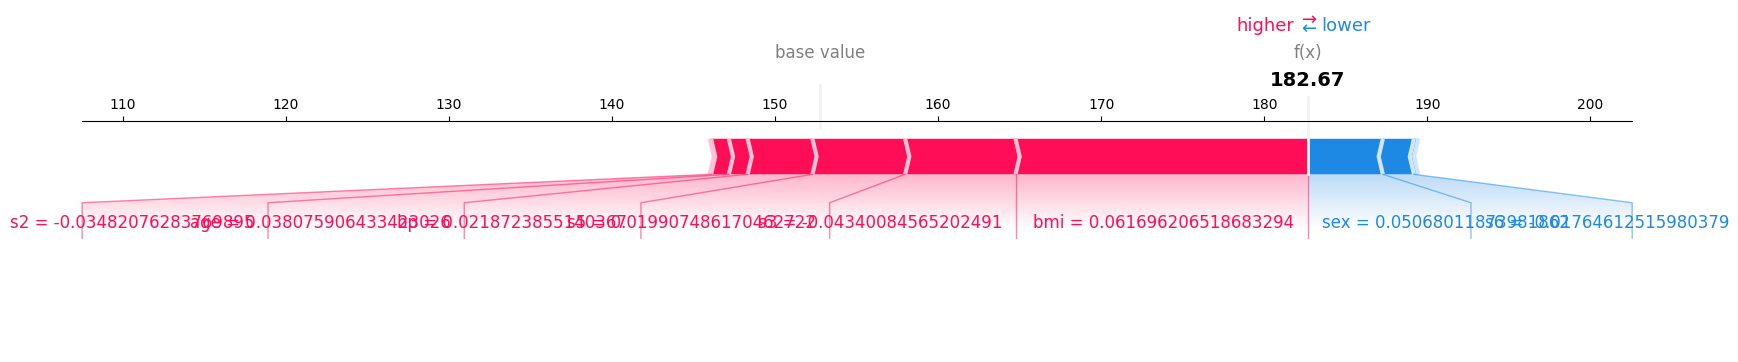


### Generated Insight
> *The xAI visualization for the diabetes progression prediction model reveals that several features significantly influence the model's prediction of 182.67. Notably, the feature "s2" has a substantial negative impact on the prediction, as indicated by the red coloration and the corresponding value of -0.0348. Conversely, "bmi" and "sex" have positive contributions, with "bmi" showing a value of 0.0616 and "sex" having a value of 0.0506. The feature "s2" appears to be the most influential, followed by "bmi" and "sex," which have lesser but still significant positive contributions. The interplay of these features suggests that higher values of "s2" reduce the predicted outcome, whereas higher values of "bmi" and "sex" increase it. This analysis underscores the importance of these specific features in the model's decision-making process for predicting diabetes progression.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Target Value Verification**: The insight correctly identifies the prediction value as 182.67, which matches the image and metadata.
2. **Visual Analysis of SHAP Force Plot**: In a SHAP force plot, red bars represent features that push the prediction higher (positive impact), and blue bars represent features that push the prediction lower (negative impact). The base value is approximately 153, and the final prediction is 182.67, meaning the net effect of the red bars is positive.
3. **Evaluating 's2'**: The insight claims 's2' has a 'substantial negative impact' and cites 'red coloration' as evidence. This is a contradiction; red coloration indicates a positive impact on the prediction.
4. **Evaluating 'bmi'**: The insight claims 'bmi' has a positive contribution. 'bmi' is associated with a red bar, so this is correct.
5. **Evaluating 'sex'**: The insight claims 'sex' has a positive contribution. However, 'sex' is associated with a blue bar, which indicates a negative contribution. This is a contradiction.
6. **Evaluating Feature Set**: All mentioned features (s2, bmi, sex) are present in the 'Features Displayed' list.
7. **Formatting**: The insight is provided as a single paragraph, adhering to formatting requirements.
* **Final State:** `Contradiction`
* **Factuality Score:** `1 / 5`
* **Instruction Score:** `5 / 5`



## CASE 8: ID `000630`
**Generator Model:** `Pixtral-12B` | **Temperature:** `0.01`


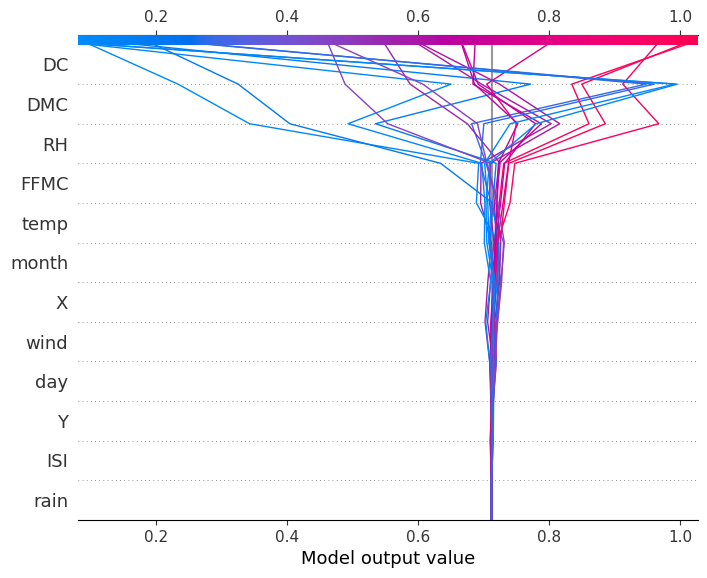


### Generated Insight
> *The provided SHAP decision plot for the SVR model used in predicting forest fire burned areas reveals several key insights into how various features influence the model's output. The features "DC," "DMC," and "RH" are prominently driving the model's decisions, with their impact visualized in both blue and red lines, indicating their positive and negative contributions to the predictions, respectively. Notably, "DC" and "DMC" have a significant positive effect when their values are lower, while "RH" shows a notable negative impact when its values are higher. "FFMC" and "temp" also play a substantial role, with "FFMC" showing a positive influence at lower values and "temp" having a negative impact at higher values. Features like "month," "day," "X," "Y," "wind," "ISI," and "rain" have less pronounced effects, suggesting they are less critical in determining the model's predictions. Overall, the magnitude of importance is highest for "DC," "DMC," and "RH," followed by "FFMC" and "temp," while the remaining features contribute minimally to the model's output.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Feature Verification**: The insight mentions DC, DMC, RH, FFMC, temp, month, day, X, Y, wind, ISI, and rain. All these features are present in the 'Features Displayed' metadata list. No unsupported claims found.
2. **Visual Analysis of SHAP Decision Plot**: 
    - The x-axis represents the 'Model output value'. Lines moving to the right increase the prediction; lines moving to the left decrease it.
    - The color bar indicates that blue represents low feature values and red represents high feature values.
    - **DC**: Red lines (high values) move right, blue lines (low values) move left. Thus, high DC increases output and low DC decreases it. The insight claims DC has a 'positive effect when their values are lower', which is a contradiction.
    - **DMC**: Red lines (high values) move right, blue lines (low values) move left. Thus, high DMC increases output and low DMC decreases it. The insight claims DMC has a 'positive effect when their values are lower', which is a contradiction.
    - **RH**: Red lines (high values) move left, blue lines (low values) move right. Thus, high RH decreases output. The insight claims RH has a 'notable negative impact when its values are higher', which is correct.
    - **FFMC**: Red lines (high values) move right, blue lines (low values) move left. The insight claims FFMC has a 'positive influence at lower values', which is a contradiction.
    - **temp**: Red lines (high values) move right, blue lines (low values) move left. The insight claims temp has a 'negative impact at higher values', which is a contradiction.
    - **Relative Importance**: The insight correctly identifies DC, DMC, and RH as the most influential (widest spread), followed by FFMC and temp, with others being minimal. This part is correct.
3. **Formatting Check**: The insight is provided as a single paragraph, adhering to the formatting requirement.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 9: ID `000042`
**Generator Model:** `Pixtral-12B` | **Temperature:** `0.4`


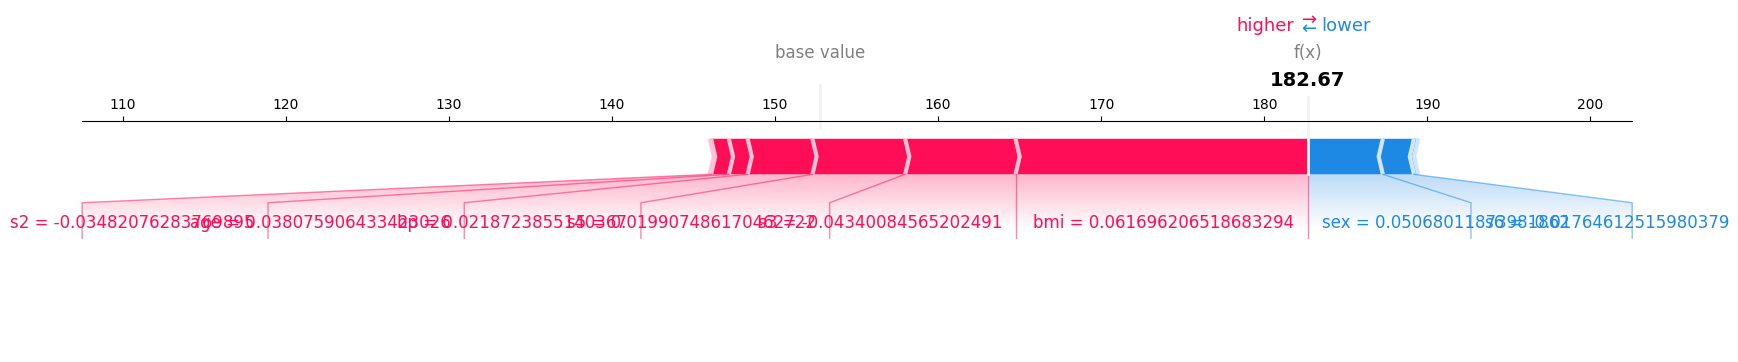


### Generated Insight
> *The provided xAI visualization for the Ridge model used in predicting diabetes progression reveals several key insights. The target value being analyzed is 182.67. The graph shows that the feature "s1" has a significant positive impact on the prediction, as indicated by the red color, suggesting that higher values of "s1" lead to higher predicted outcomes. Conversely, "s2" has a notable negative effect, with higher values of "s2" resulting in lower predicted outcomes, as depicted by the blue color. Features "age," "sex," and "bmi" also influence the prediction, but to a lesser extent compared to "s1" and "s2." The magnitude of their importance is relatively smaller, with "bmi" showing a slight positive impact and "age" and "sex" having minimal influence. Overall, the model's decision is primarily driven by the features "s1" and "s2," with "s1" positively impacting and "s2" negatively impacting the predicted diabetes progression value of 182.67.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Target Value Verification**: The insight correctly identifies the target value as 182.67, which matches the f(x) value in the image.
2. **Feature Direction Analysis (s1)**: The insight claims 's1' has a significant positive impact and is indicated by the red color. However, looking at the image, 's1' is located on the right side of the force plot in a blue segment, meaning it has a negative impact (pushes the prediction lower).
3. **Feature Direction Analysis (s2)**: The insight claims 's2' has a notable negative effect and is depicted by the blue color. However, the image shows 's2' on the far left in a red segment, meaning it has a positive impact (pushes the prediction higher).
4. **Other Features**: The insight correctly identifies 'bmi' as having a positive impact (red) and 'age' and 'sex' as having smaller influences. 
5. **Unsupported Claims**: All mentioned features (s1, s2, age, sex, bmi) are present in the 'Features Displayed' metadata list.
6. **Formatting**: The insight is provided as a single paragraph, adhering to formatting requirements.
7. **Conclusion**: There is a direct contradiction regarding the impact directions of the two primary features (s1 and s2).
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 10: ID `000975`
**Generator Model:** `Pixtral-12B` | **Temperature:** `0.4`


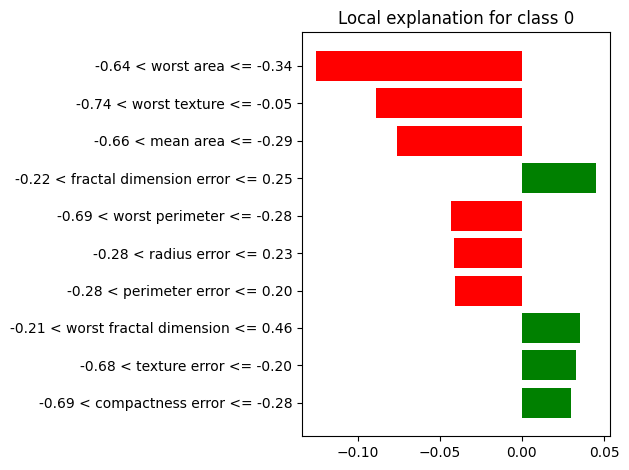


### Generated Insight
> *The visual graph provides a detailed local explanation for the classification of a sample as class 0 (malignant) in a breast cancer classification model. The features driving the model's decision predominantly include "worst area," "worst texture," and "mean area," which have significant negative contributions, indicating that higher values in these features are associated with the malignant classification. Among these, "worst texture" has the most substantial negative impact, followed by "worst area" and "mean area." Other notable features with negative contributions include "worst perimeter," "radius error," and "perimeter error." Conversely, features like "fractal dimension error" and "worst fractal dimension" have smaller positive contributions, suggesting that lower values in these features slightly mitigate the malignant classification. The magnitude of these contributions indicates a clear prioritization, with "worst texture" being the most critical feature influencing the model's decision, followed by "worst area" and "mean area." This analysis underscores the importance of textural and size-related attributes in determining the classification outcome for this particular sample.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Feature Verification**: All features mentioned in the insight ('worst area', 'worst texture', 'mean area', 'worst perimeter', 'radius error', 'perimeter error', 'fractal dimension error', 'worst fractal dimension') are present in the 'Features Displayed' metadata list and the provided image. No unsupported claims were made regarding feature names.
2. **Magnitude/Ranking Analysis**: The insight claims that 'worst texture' has the most substantial negative impact, followed by 'worst area' and 'mean area'. However, visual inspection of the bar chart shows that 'worst area' has the longest red bar (most negative value, approx -0.12), followed by 'worst texture' (approx -0.09), and then 'mean area' (approx -0.07). The insight incorrectly ranks the features.
3. **Direction/Sign Analysis**: The insight states that 'negative contributions' indicate that features are 'associated with the malignant classification' (class 0). In a LIME local explanation for a specific class, a negative contribution (red bar) means that the feature value decreases the probability of the sample belonging to that class. Therefore, negative contributions actually indicate that these features push the prediction *away* from the malignant classification, contradicting the insight's claim.
4. **Formatting**: The insight is provided as a single paragraph, adhering to the formatting requirements.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 11: ID `000279`
**Generator Model:** `Pixtral-12B` | **Temperature:** `0.2`


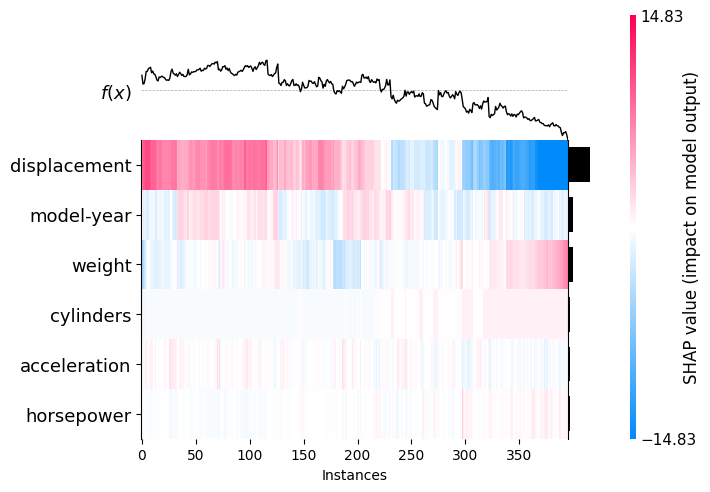


### Generated Insight
> *The heatmap visualization using SHAP values provides a detailed overview of how various features influence the model's prediction of fuel efficiency in automotive data. The features analyzed include displacement, model-year, weight, cylinders, acceleration, and horsepower. The color gradient from blue to red indicates the direction of the feature's impact on the model output, with blue representing a negative impact and red a positive impact. Displacement and weight show a significant positive impact on the model's output, as indicated by the prevalence of red shades across many instances, suggesting that higher values in these features tend to increase the predicted fuel efficiency. Conversely, features like cylinders and horsepower exhibit a more mixed impact, with both positive and negative contributions across different instances. Model-year and acceleration have less consistent patterns, indicating their influence varies more widely across different data points. Overall, displacement and weight are the most impactful features, while cylinders and horsepower have more nuanced and variable effects on the model's predictions.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Feature Verification**: The insight mentions displacement, model-year, weight, cylinders, acceleration, and horsepower. All these features are listed in the 'Features Displayed' metadata and are present on the y-axis of the heatmap. No unsupported claims regarding features were made.
2. **Visual Analysis of SHAP Values**: 
    - The x-axis represents instances, and the line plot at the top shows the model output $f(x)$, which is high on the left and low on the right.
    - For 'displacement', the heatmap is red (positive SHAP) on the left and blue (negative SHAP) on the right. This indicates that for instances with high predicted fuel efficiency, displacement contributes positively.
    - For 'weight', the heatmap is blue (negative SHAP) on the left and red (positive SHAP) on the right. This indicates that for instances with high predicted fuel efficiency, weight contributes negatively (pushes the prediction down).
3. **Evaluating the Insight's Claim**: The insight states that 'Displacement and weight show a significant positive impact... suggesting that higher values in these features tend to increase the predicted fuel efficiency.' This is a contradiction. While displacement follows this pattern (red where $f(x)$ is high), weight follows the opposite pattern (blue where $f(x)$ is high). Therefore, weight actually has a negative impact on the model's higher predictions.
4. **Formatting Check**: The insight is provided as a single paragraph, adhering to the formatting requirements.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 12: ID `001074`
**Generator Model:** `Pixtral-12B` | **Temperature:** `0.01`


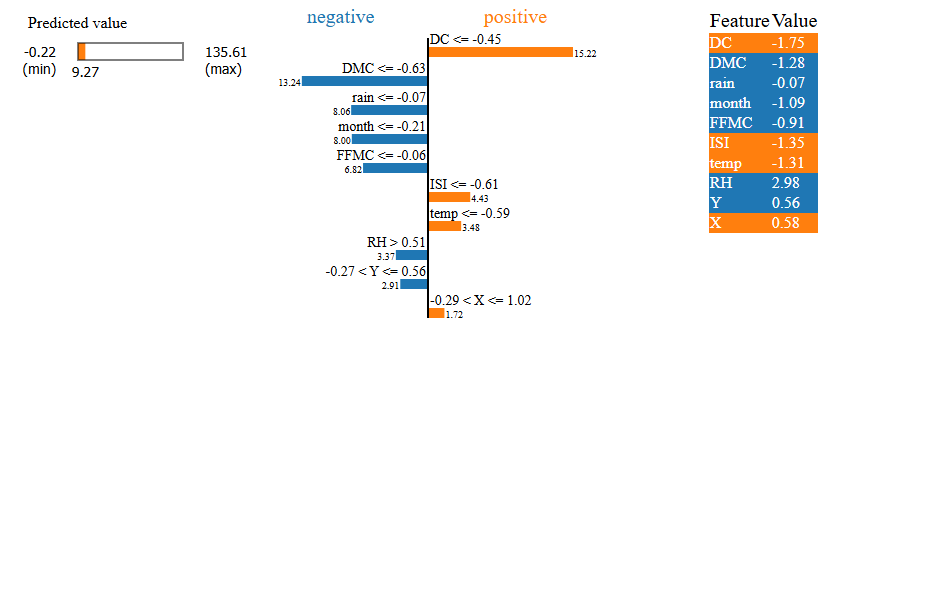


### Generated Insight
> *The visual graph illustrates the impact of various features on the model's prediction for forest fire burned area. The most significant feature driving the decision is "DC," which has a substantial negative impact with a value of -1.75, contributing to a lower predicted value. Other features with notable negative contributions include "DMC" (-1.28), "month" (-1.09), and "FFMC" (-0.91). Conversely, "RH" has a positive impact, increasing the prediction with a value of 2.98. Features such as "rain," "day," and "temp" also have minor negative contributions, while "ISI" has a moderate negative impact. The feature "X" has a small positive contribution, and "Y" has a slight negative effect. Overall, the model's prediction is predominantly influenced by the negative contributions of "DC" and "DMC," with "RH" providing a counterbalancing positive effect.*

### Judge's Output 
* **Chain of Thought Reasoning:** I analyzed the generated insight against the provided image and metadata. 
1. **Feature Value vs. Impact Confusion**: The insight consistently confuses the 'Feature Value' (the actual value of the feature for this instance) with the 'Impact' (the weight/contribution shown by the bars). For example, it claims DC has a 'negative impact with a value of -1.75', but -1.75 is the feature value, while the impact is positive (orange bar, value 15.22).
2. **Directional Contradictions**: 
    - DC: Insight says negative impact; Image shows positive (orange bar).
    - RH: Insight says positive impact; Image shows negative (blue bar).
    - temp: Insight says negative contribution; Image shows positive (orange bar).
    - ISI: Insight says negative impact; Image shows positive (orange bar).
3. **Unsupported Claims**: The insight mentions 'day'. While 'day' is in the 'Features Displayed' metadata list, it is not present in the visual graph. However, per the specific task instruction to check if it mentions features NOT in the 'Features Displayed' list, this is not an unsupported claim.
4. **Formatting**: The insight is a single paragraph, which follows the formatting requirement.
* **Final State:** `Contradiction`
* **Factuality Score:** `1 / 5`
* **Instruction Score:** `5 / 5`



## CASE 13: ID `000356`
**Generator Model:** `Qwen-3-VL-8B` | **Temperature:** `0.01`


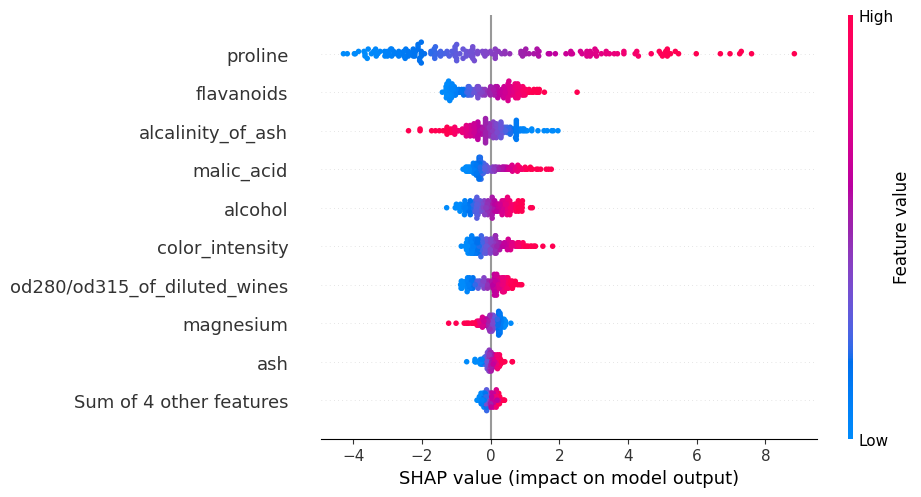


### Generated Insight
> *Based on the SHAP beeswarm plot for the logistic regression model predicting wine cultivar class_0, the most influential features driving the model’s decision are proline, flavanoids, and alcohol, which exhibit strong positive SHAP values, indicating they increase the likelihood of the target class. Proline shows the highest magnitude of positive impact, followed closely by flavanoids and alcohol, suggesting these chemical properties are key discriminators. Conversely, features such as malic_acid, ash, and magnesium display negative SHAP values, meaning higher values of these features decrease the model’s predicted probability for class_0. The magnitude of impact is visually ordered by the spread and density of points along the x-axis, with proline and flavanoids showing the widest spread and highest concentration of positive values, while features like alcalinity_of_ash and magnesium show more moderate and mixed impacts. The “Sum of 4 other features” category, positioned near the center, indicates a relatively neutral or low-impact contribution to the model’s output.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. Feature Verification: The insight mentions proline, flavanoids, alcohol, malic_acid, ash, magnesium, and alcalinity_of_ash. All these are listed in the 'Features Displayed' metadata and appear in the image. The 'Sum of 4 other features' is a standard SHAP aggregation shown in the plot.
2. Directional Analysis (Positive): The insight states that proline, flavanoids, and alcohol have strong positive SHAP values for high feature values (red dots). Looking at the plot, the red dots for these three features are indeed located to the right of the zero line. This is correct.
3. Directional Analysis (Negative): The insight claims that 'malic_acid, ash, and magnesium display negative SHAP values, meaning higher values of these features decrease the model’s predicted probability'. Checking the plot: 
    - Magnesium: Red dots are on the left (negative). Correct.
    - Malic_acid: Red dots are on the right (positive). Contradiction.
    - Ash: Red dots are on the right (positive). Contradiction.
4. Magnitude Analysis: The insight correctly identifies proline as having the highest magnitude of impact based on the x-axis spread.
5. Formatting: The insight is provided as a single paragraph, adhering to the formatting requirement.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 14: ID `000630`
**Generator Model:** `Qwen-3-VL-8B` | **Temperature:** `0.4`


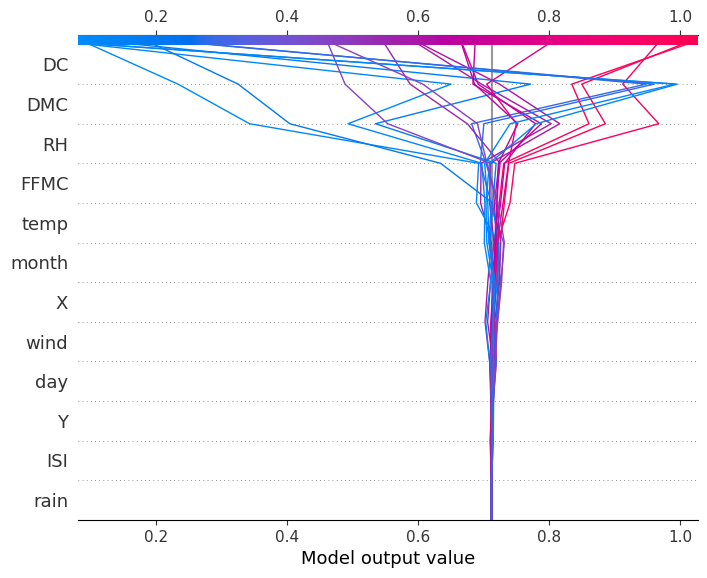


### Generated Insight
> *Based on the SHAP PermutationExplainer visualization for the SVR forest fire burned area prediction model, the most influential features driving the model's decision are 'DC' (Duff Consumption), 'DMC' (Duff Moisture Code), and 'FFMC' (Fine Fuel Moisture Code), which collectively exhibit strong positive contributions to the model output, indicating that higher values of these fire behavior indices are associated with larger predicted burned areas. These are followed by 'temp' (temperature) and 'RH' (relative humidity), which also show significant positive influence, suggesting that hotter and drier conditions increase fire risk. The features 'X' and 'Y' (spatial coordinates) appear to have a relatively minor impact, while'month', 'day', 'wind', and 'rain' show moderate to low influence, with 'rain' potentially having a negative effect (as suggested by its position on the lower end of the x-axis). The magnitude of importance is visually ordered by the spread and density of the lines: 'DC', 'DMC', and 'FFMC' dominate the upper portion of the plot, indicating their largest contribution to model output variance, followed by 'temp' and 'RH', with the remaining features showing progressively smaller effects.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Feature Verification**: All features mentioned in the insight ('DC', 'DMC', 'FFMC', 'temp', 'RH', 'X', 'Y', 'month', 'day', 'wind', 'rain') are present in the 'Features Displayed' metadata list. No unsupported claims regarding feature names.
2. **Influence Analysis**: The insight identifies 'DC', 'DMC', and 'FFMC' as the most influential. Looking at the SHAP decision plot, the spread of the lines (which indicates the magnitude of the feature's impact on the model output) is widest for 'DC' and 'DMC'. However, 'RH' (Relative Humidity) shows a significantly wider spread than 'FFMC'. Therefore, claiming 'FFMC' is among the top three most influential while placing 'RH' in a secondary group is a contradiction of the visual evidence.
3. **Directional Analysis**: The insight claims 'rain' potentially has a negative effect. In the plot, the lines for 'rain' are almost perfectly vertical, aligned with the base value (approx 0.7). This indicates that 'rain' has negligible to zero impact on the model output for this cohort, not a negative effect.
4. **Formatting Check**: The insight is provided as a single paragraph, adhering to the formatting requirements.
5. **Conclusion**: Because the insight misrepresents the relative importance of 'FFMC' vs 'RH' and hallucinates a negative effect for 'rain' where the plot shows no effect, it contains factual contradictions.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 15: ID `000042`
**Generator Model:** `Qwen-3-VL-8B` | **Temperature:** `0.2`


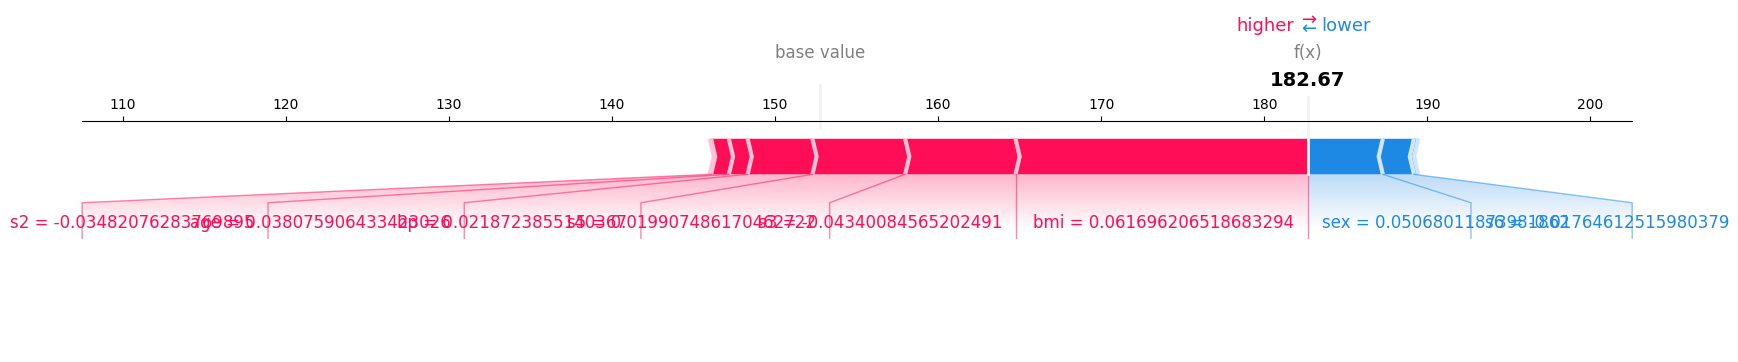


### Generated Insight
> *In this local SHAP force plot for a Ridge regression model predicting a target value of 182.67, the model's decision is primarily driven by the features 'age', 'bmi', and 'bp', which exhibit the largest positive contributions, pulling the prediction upward. The feature's2' shows the most significant negative impact, acting as a strong counterforce that pulls the prediction downward. The remaining features—'sex','s1','s3','s4','s5','s6'—contribute minimally, with'sex' showing a small positive contribution and the others appearing near zero, indicating they have negligible influence on this specific prediction. The magnitude of impact is ordered as:'s2' (strong negative) > 'age' > 'bmi' > 'bp' >'sex' (small positive), with the other features contributing negligibly to the final value.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Target Value Verification**: The insight correctly identifies the target value as 182.67, which matches the image and metadata.
2. **Direction of Impact (Positive/Negative)**: In a SHAP force plot, red bars push the prediction higher (positive contribution) and blue bars push it lower (negative contribution). 
    - The image shows that 'bmi', 'bp', 'age', 's1', 's2', 's3', 's4', 's5', and 's6' are all red, meaning they contribute positively to the increase from the base value (~154) to the final value (182.67).
    - The image shows that 'sex' is blue, meaning it contributes negatively (pulling the prediction down).
    - The insight claims 's2' has a 'significant negative impact' and acts as a 'counterforce'. This is a direct contradiction; 's2' is red (positive).
    - The insight claims 'sex' shows a 'small positive contribution'. This is a direct contradiction; 'sex' is blue (negative).
3. **Magnitude of Impact**: 
    - Visually, 'bmi' is the largest red bar, indicating it has the most significant positive impact.
    - The insight claims the magnitude order is 's2' (strong negative) > 'age' > 'bmi'. This is incorrect; 'bmi' is clearly larger than 'age' and 's2'.
4. **Feature Set**: All features mentioned ('age', 'bmi', 'bp', 's2', 'sex', 's1', 's3', 's4', 's5', 's6') are present in the 'Features Displayed' list.
5. **Formatting**: The insight is provided as a single paragraph, adhering to formatting requirements.
* **Final State:** `Contradiction`
* **Factuality Score:** `1 / 5`
* **Instruction Score:** `5 / 5`



## CASE 16: ID `000042`
**Generator Model:** `Qwen-3-VL-8B` | **Temperature:** `0.01`


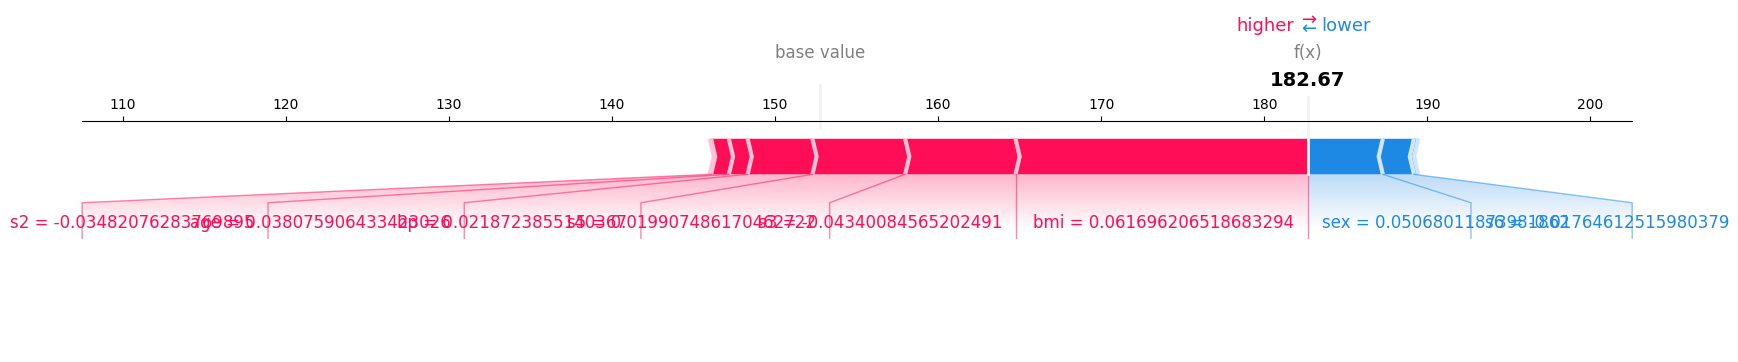


### Generated Insight
> *In this local SHAP force plot for a Ridge regression model predicting a target value of 182.67, the model's decision is primarily driven by three features: 'age' (with a strong positive contribution, indicated by its large red segment), 'bmi' (also positive, with a substantial red segment), and's2' (with a strong negative contribution, shown by its large red segment extending leftward). The direction of impact is clear: higher 'age' and 'bmi' values increase the predicted outcome, while higher's2' values decrease it. In terms of magnitude, 'age' appears to be the most influential feature, followed by 'bmi', with's2' being the second most influential negative feature. The remaining features ('sex', 'bp','s1','s3','s4','s5','s6') contribute minimally, as their segments are small and mostly neutral or slightly positive, indicating they have a negligible effect on this specific prediction.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Metadata Verification**: The insight correctly identifies the model (Ridge), the target value (182.67), and the plot type (local SHAP force plot). All features mentioned ('age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6') are present in the 'Features Displayed' list.
2. **Visual Analysis of SHAP Force Plot**: In a SHAP force plot, red segments represent features that push the prediction higher (positive contribution), and blue segments represent features that push the prediction lower (negative contribution). The base value is approximately 153, and the final prediction is 182.67. The red segments extend from the base value to the right, increasing the value.
3. **Evaluating Claims**: 
    - The insight claims 'age' and 'bmi' have positive contributions (red segments). This is visually correct.
    - The insight claims 's2' has a 'strong negative contribution' and describes it as a 'red segment extending leftward'. This is a direct contradiction of how SHAP force plots work: red is always positive, and in this specific image, the red segments are extending rightward from the base value to increase the prediction. 
    - The insight further claims that higher 's2' values decrease the outcome, which contradicts the visual evidence of 's2' being a red (positive) contributor.
4. **Formatting**: The insight is provided as a single paragraph, adhering to formatting requirements.
* **Final State:** `Contradiction`
* **Factuality Score:** `2 / 5`
* **Instruction Score:** `5 / 5`



## CASE 17: ID `001204`
**Generator Model:** `Qwen-3-VL-8B` | **Temperature:** `0.01`


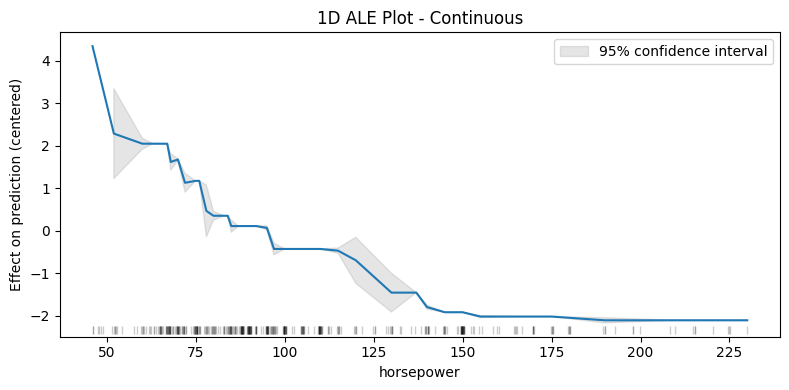


### Generated Insight
> *The 1D ALE plot for the 'horsepower' feature reveals that higher horsepower values exert a consistently negative effect on fuel efficiency (MPG), as indicated by the downward-sloping blue line, which signifies that as horsepower increases, the predicted MPG decreases. The magnitude of this negative impact is substantial, beginning at approximately 4.0 for low horsepower (around 50) and declining to around -2.0 for very high horsepower (above 200), suggesting that high horsepower engines are strongly associated with lower fuel efficiency. The 95% confidence interval, shown as the shaded gray region, remains relatively narrow and consistently below zero across the entire range, reinforcing the statistical confidence in this negative relationship. The feature's global importance is evident from the large, continuous effect observed across the entire domain, indicating that 'horsepower' is a dominant driver of the model's predictions for fuel efficiency.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. Metadata Verification: The feature displayed is 'horsepower' and the target is fuel efficiency (MPG), which matches the insight. 2. Trend Analysis: The blue line in the 1D ALE plot shows a clear downward trend, starting at approximately 4.0 for horsepower ~50 and ending at approximately -2.0 for horsepower > 200. This part of the insight is factually correct. 3. Confidence Interval Analysis: The insight claims that the 95% confidence interval (shaded gray region) 'remains relatively narrow and consistently below zero across the entire range'. Looking at the image, the shaded region is clearly above zero for horsepower values between 50 and approximately 100. Therefore, the claim that it is 'consistently below zero across the entire range' is a direct contradiction of the visual evidence. 4. Feature Check: No features other than 'horsepower' were mentioned. 5. Formatting Check: The insight is presented as a single paragraph.
* **Final State:** `Contradiction`
* **Factuality Score:** `3 / 5`
* **Instruction Score:** `5 / 5`



## CASE 18: ID `000042`
**Generator Model:** `Qwen-3-VL-8B` | **Temperature:** `0.4`


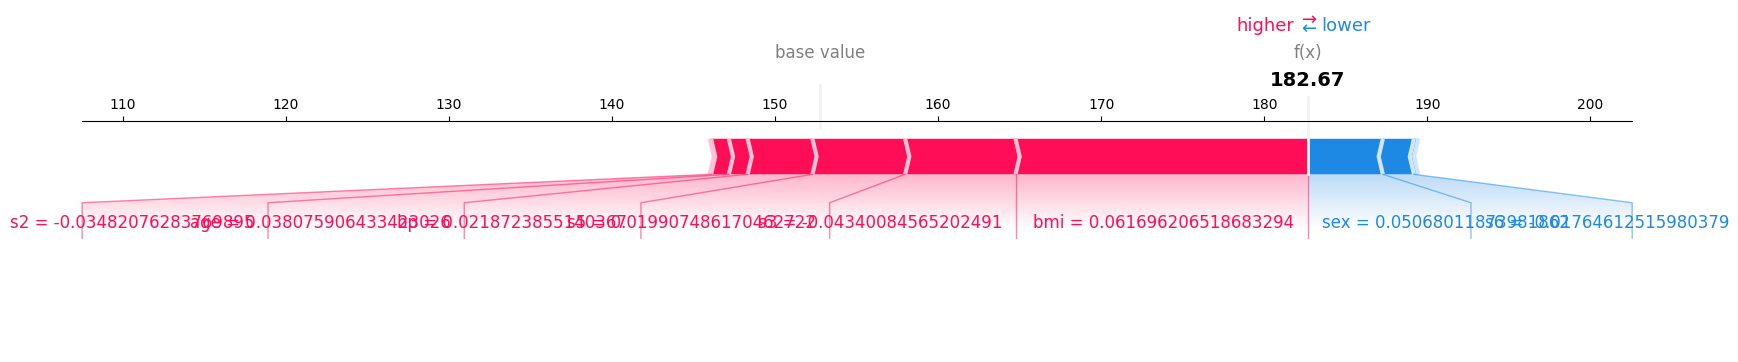


### Generated Insight
> *In this local SHAP force plot for a Ridge regression model predicting a target value of 182.67, the model’s decision is primarily driven by age, which exhibits a strong positive contribution, followed by bmi and sex, which also contribute positively but to a lesser extent. The feature s2 shows a significant negative impact, pulling the prediction down, while s1, s3, s4, s5, and s6 have minimal or negligible influence on the outcome. The magnitude of impact is ordered as: age > bmi > sex > s2, with age being the dominant driver due to its large positive contribution, followed by bmi and sex which add to the prediction, and s2 which acts as a counteracting negative factor.*

### Judge's Output 
* **Chain of Thought Reasoning:** 1. **Analyze Metadata**: The target value is 182.67, the model is Ridge, and the plot is a SHAP force plot. Features displayed include age, sex, bmi, bp, s1-s6.
2. **Analyze Image**: 
    - The base value is approximately 153.
    - Red bars (positive contributions) push the prediction from the base value up to approximately 185. These features include bmi, age, bp, s1, s3, s4, s5, s6, and s2.
    - Blue bars (negative contributions) push the prediction back down from ~185 to the final value of 182.67. The most prominent blue bar is 'sex'.
    - The largest red bar (strongest positive driver) is 'bmi', not 'age'.
3. **Evaluate Insight Claims**:
    - Claim: 'primarily driven by age' -> Contradiction. 'bmi' has the largest red bar.
    - Claim: 'bmi and sex... contribute positively' -> Contradiction. 'sex' is represented by a blue bar, meaning it contributes negatively.
    - Claim: 's2 shows a significant negative impact' -> Contradiction. 's2' is represented by a red bar, meaning it contributes positively.
    - Claim: 'magnitude of impact is ordered as: age > bmi > sex > s2' -> Contradiction. 'bmi' is larger than 'age'.
4. **Check Constraints**: 
    - Unsupported Claims: None. All mentioned features are in the metadata list.
    - Formatting: The insight is a single paragraph. No formatting error.
    - Contradictions: Multiple severe contradictions regarding the direction (positive/negative) and magnitude of feature impacts.
* **Final State:** `Contradiction`
* **Factuality Score:** `1 / 5`
* **Instruction Score:** `5 / 5`


In [4]:
import pandas as pd
import os
from IPython.display import display, HTML, Markdown, Image

# SETUP PATHS

PROJECT_ROOT = ".." 
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "xai_rag_cbr", "data", "raw")
BASE_CASE_CSV = os.path.join(RAW_DATA_PATH, "xai_case_base.csv")

OUTPUTS_CSV = "temperature_experiment_outputs.csv"
EVALS_CSV = "temperature_experiment_evaluation.csv"


# LOAD & MERGE DATA

# Read the dataframes, ensuring IDs stay as strings
outputs_df = pd.read_csv(OUTPUTS_CSV, dtype={'case_id': str})
evals_df = pd.read_csv(EVALS_CSV, dtype={'case_id': str})
base_df = pd.read_csv(BASE_CASE_CSV, dtype={'id': str})

# Merge outputs and evaluations (on all three keys to ensure perfect alignment) so we have the insight and the scores in one df
merged_df = pd.merge(outputs_df, evals_df, on=['case_id', 'model', 'temperature'])


# STRATIFIED SAMPLING

# We group by the 'model' column and sample exactly 6 random rows from each group (18 total)
sampled_df = merged_df.groupby('model').sample(n=6, random_state=42).reset_index(drop=True) # Fix random_state for reproducibility


# PRINT FOR VISUAL INSPECTION

for index, row in sampled_df.iterrows():

    case_id = str(row['case_id']).zfill(6)
    
    # Extract the image filename from the base case database and construct the path
    img_filename = base_df[base_df['id'] == case_id]['img_path'].values[0]
    img_path = os.path.join(RAW_DATA_PATH, img_filename)

    # HTML SEPARATOR
    display(HTML('<br><hr style="height:4px;border:none;color:#333;background-color:#333;" />'))
    
    # HEADER
    header = f"""
## CASE {index + 1}: ID `{case_id}`
**Generator Model:** `{row['model']}` | **Temperature:** `{row['temperature']}`
"""
    display(Markdown(header))
    
    # GRAPH
    if os.path.exists(img_path):
        display(Image(filename=img_path, width=600))
    else:
        display(Markdown(f"*(Image not found at {img_path})*"))
        
    # TEXT & EVALUATION (blockquotes for the insight and bold text for the scores for clear visual interpretation)
    report = f"""
### Generated Insight
> *{row['generated_insight']}*

### Judge's Output 
* **Chain of Thought Reasoning:** {row['chain_of_thought_reasoning']}
* **Final State:** `{row['response_state']}`
* **Factuality Score:** `{row['factuality_score']} / 5`
* **Instruction Score:** `{row['instruction_following_score']} / 5`
"""
    display(Markdown(report))

The results of the validation provide strong evidence supporting the reliability of the LLM-as-a-judge approach used in this experiment. Overall, there is a high level of agreement between the human expert knowledge evaluation and the judge model across all assessed dimensions. In order to compare both, human scores and state were obtained for each reviewed case before comparing with the judge output. After the scores, the chain-of-thoughts generated by the judge was also reviewed. Breaking down by category:
* First, a complete match was observed in all instruction-following scores, indicating that the judge consistently and accurately evaluates whether the outputs adhere to the required format and guidelines. 
* Similarly, the classification of response states showed near-perfect agreement, with only one discrepancy out of 18 cases. In this instance, the judge labeled the response as a contradiction, while the human evaluation considered it acceptable, suggesting that the judge may apply slightly stricter criteria in certain cases.
* Regarding factuality, the agreement rate was moderate (approximately 55%), but importantly, all disagreements were minor, with a maximum difference of one point. These differences can be attributed to two main factors: in some cases, the judge was perceived as overly strict when penalizing less relevant issues, while in others it either overlooked or hallucinated features that impacted the factual correctness of the evaluation. Despite this, the overall alignment remains strong and consistent.
* Finally, the judge model demonstrated a high level of evaluation capability. It was considered to produce a perfect evaluation in 6 cases, a good evaluation in 8 cases (capturing the main issues despite minor omissions or limited explanations), and a weaker evaluation in only 4 cases, where more significant hallucinations or misinterpretations occurred. This distribution further supports the robustness of the evaluation process.

These results validate the use of the LLM-as-a-judge as a reliable evaluation mechanism in this context. The high agreement with human expert knowledge, combined with the relatively small magnitude of discrepancies, indicates that the conclusions drawn from the automated evaluation can be considered trustworthy. This validation step is essential, as it ensures that the evaluation framework itself is sound and reduces the risk of propagating errors from the judge model into the final results of the experiment.

Two additional observations emerged during the analysis:
* First, the "Contradiction" label may be overly severe in certain cases. Some responses that were largely correct and coherent were classified as contradictions due to minor inaccuracies. This may partially explain why the error distribution (in the stacked bar chart) appears more critical than what is observed during manual inspection. However, maintaining strict and objective classification criteria was necessary to ensure consistency across evaluations.
* Second, certain types of visualizations proved particularly challenging for both the evaluated models and the judge. In particular, SHAP force plots and SHAP heatmaps were the most error-prone. Their visual complexity, such as overlapping elements, dense feature representations, and the need to interpret multiple visual components simultaneously, makes them difficult to analyse accurately, even for advanced models.

## Conclusion

Taking into account the results obtained from the LLM-as-a-judge evaluation, together with the human expert validation, we determine the final optimal temperature configuration for the three LLMs:
* **Pixtral-12B:** across all three graphs obtained, **T=0.4** was the strongest choice. In the heatmap from section 4.1 it achieves the highest average factuality (3.10), in the stacked bar chart from section 4.2 it ties with *T=0.01* for the most "Perfect" responses (3/10) for  error typology and in the box plot from section 4.3 it obtains the highest median in the with an upward-shifted distribution. In fact, this is the best combination across all three models according to results. The highest tested temperature proves that some degree of generation diversity benefits the outputs for Pixtral.
* **Qwen-3-VL-8B:** the better choice for Qwen is **T=0.01**. The heatmap from section 4.1 clearly favors this configuration over the other options and the box plot from section 4.3 shows a slightly higher and wider distribution at this setting. Although the stacked bar from section 4.2 shows no "Perfect" responses (vs 1 at T=0.2), the overall factuality distribution compensates because it does't depend on a random outlier. The lowest temperature benefits this model's factual grounding.
* **Idefics3-8B:** even though this was the model that struggled the most during evaluation, the best configuration for Idefics is **T=0.2**. In the stacked bar chart from section 4.2, all three temperatures tie with all cases classed as "Contradiction". It is in the heatmap from section 4.1 and in the box plot from section 4.3 where this temperature beats the other options, offering the highest average factuality (1.40) and a slightly higher and wider distribution.

To sum up, we adopt a model-specific approach to temperature selection, choosing the best-performing configuration for each LLM. This allows us to maximise factual accuracy by adjusting the generation settings to the behaviour and strengths of each individual model.

Furthermore, there are two relevant insights for improving the main system we would like to highlight:
* On one hand, the judge model consistently demonstrated stronger analytical capabilities than the evaluated models, likely due to its larger size. However, another key differentiating factor was the inclusion of structured reasoning (chain-of-thought) in the prompt. It has been shown that incorporating intermediate reasoning steps can significantly improve the performance and reliability of LLM-based systems, particularly in technical tasks such as the analysis of data visualizations. This suggests that integrating similar reasoning strategies into the generation prompts of the evaluated models, especially for the main case base generation, could lead to improved factual performance.
* On the other hand, it was observed that both the models and the judge occasionally hallucinated about features listed in the metadata but not visibly present in the graph. Rather than removing this information from the prompt, we refine its formulation to clarify that it represents the set of possible features, not all of which are necessarily shown in the visualization. This allows the metadata to remain a useful guide while encouraging the models to prioritise visual evidence when identifying relevant features. In fact, the original label used in the prompts(“Features Displayed”) may have contributed to this confusion, as it implicitly suggested that all listed features were present in the graph.